# Red neuronal artificial para reconocer el tipo de un pokemon

> **Integrantes:** Eduardo Jared Montecinos, Jose Cristobal Silva, Matías Toledo

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

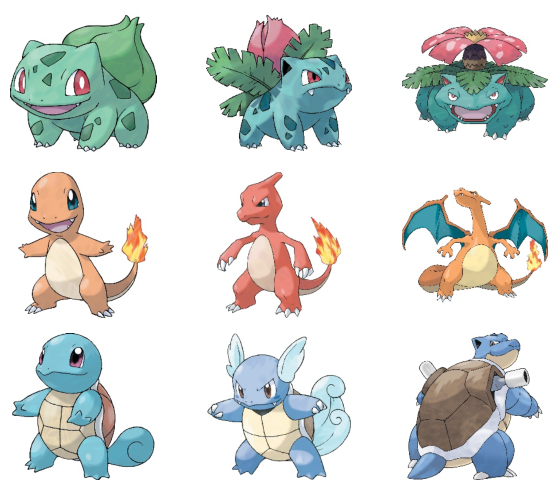

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');


In [2]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

In [3]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


In [4]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

print(f"Total imágenes: {len(train_dataset)}")

Total imágenes: 505


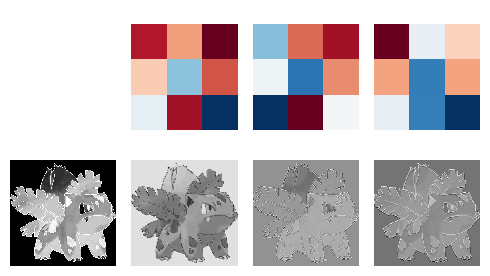

In [5]:
# Probando copiado machine learning book
import torch.nn as nn

conv_layer = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3)

example_image = train_dataset[0][0]
result = conv_layer(example_image)
example_image.shape, result.shape

fig, ax = plt.subplots(2, 4, figsize=(5, 3), tight_layout=True)
ax[1, 0].matshow(example_image[0], cmap=plt.cm.Greys)
ax[0, 0].axis('off')
ax[1, 0].axis('off')
for ax_, conv_filter in zip(ax[0, 1:], conv_layer.weight.detach().numpy()):
    ax_.matshow(conv_filter[0], cmap=plt.cm.RdBu)
    ax_.axis('off')
    
for ax_, filtered_image in zip(ax[1, 1:], result.detach().numpy()):
    ax_.matshow(filtered_image, cmap=plt.cm.Greys)
    ax_.axis('off')

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus decisiones de diseño.

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

class PokemonClassifier(nn.Module):
    """
    Modelo multimodal: backbone EfficientNet-B0 (imagen) + MLP (atributos).
    Ambas ramas se fusionan antes del clasificador final.
    """
    def __init__(self, num_classes=18, num_attributes=6, hidden_dim=256):
        super().__init__()

        # Normalización ImageNet requerida por el backbone preentrenado
        self.register_buffer('img_mean',
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('img_std',
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

        # Backbone: EfficientNet-B0 preentrenado en ImageNet
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        # Congelamos todo el backbone; solo descongelamos las 2 últimas etapas
        for param in backbone.parameters():
            param.requires_grad = False
        for param in backbone.features[6:].parameters():
            param.requires_grad = True

        self.image_features = backbone.features  # salida: (B, 1280, H', W')
        self.image_pool     = backbone.avgpool   # AdaptiveAvgPool -> (B, 1280, 1, 1)
        image_out_dim = 1280

        # Rama de atributos numéricos (HP, Attack, Defense, Speed, Height, Weight)
        self.attribute_branch = nn.Sequential(
            nn.Linear(num_attributes, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # Clasificador conjunto (imagen + atributos)
        self.classifier = nn.Sequential(
            nn.Linear(image_out_dim + 64, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, images, attributes):
        # Redimensionar a 224×224 (tamaño esperado por EfficientNet)
        images = torch.nn.functional.interpolate(
            images, size=(224, 224), mode='bilinear', align_corners=False
        )
        # Normalización ImageNet
        images = (images - self.img_mean) / self.img_std

        # Rama imagen
        z_img  = self.image_pool(self.image_features(images)).flatten(1)  # (B, 1280)

        # Rama atributos
        z_attr = self.attribute_branch(attributes)  # (B, 64)

        # Fusión y clasificación
        return self.classifier(torch.cat([z_img, z_attr], dim=1))


model = PokemonClassifier(num_classes=len(dataset.categories))
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:     {n_total:,}")
print(f"Parámetros entrenables: {n_trainable:,}")

Parámetros totales:     4,361,742
Parámetros entrenables: 3,509,934


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

In [7]:
import torch
import torch.utils.data as tdata
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from tqdm import tqdm

# --- Split estratificado train / valid sobre train_dataset ---
total      = len(train_dataset)
all_labels = [train_dataset[i][1] for i in range(total)]

tr_idx, val_idx = train_test_split(
    np.arange(total), test_size=0.2, random_state=1234,
    shuffle=True, stratify=all_labels
)
poke_train = Subset(train_dataset, tr_idx)
poke_valid = Subset(train_dataset, val_idx)

# --- WeightedRandomSampler: iguala la frecuencia de clases en cada batch ---
train_labels_arr = np.array(all_labels)[tr_idx]
class_counts   = Counter(train_labels_arr)
sample_weights = torch.tensor(
    [1.0 / class_counts[l] for l in train_labels_arr], dtype=torch.float
)
sampler = tdata.WeightedRandomSampler(
    sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = tdata.DataLoader(poke_train, batch_size=32, sampler=sampler)
valid_loader = tdata.DataLoader(poke_valid, batch_size=64,  shuffle=False)

# --- Pesos de clase para CrossEntropyLoss (doble cobertura del desbalance) ---
num_classes      = len(dataset.categories)
all_class_counts = Counter(dataset.labels)
loss_weights     = torch.tensor(
    [1.0 / all_class_counts.get(c, 1) for c in range(num_classes)],
    dtype=torch.float
)

# --- Dispositivo, modelo, criterio ---
device    = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print (f"Usando dispositivo: {device}")
model     = PokemonClassifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights.to(device))

# Tasas de aprendizaje diferenciadas: menor para el backbone (fine-tuning)
optimizer = torch.optim.AdamW([
    {'params': model.image_features.parameters(), 'lr': 5e-5},
    {'params': model.attribute_branch.parameters(), 'lr': 3e-4},
    {'params': model.classifier.parameters(),       'lr': 3e-4},
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6
)

# --- Función única para entrenamiento y evaluación ---
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for images, labels, _, attributes in loader:
            images, labels, attributes = (
                images.to(device), labels.to(device), attributes.to(device)
            )
            if training:
                optimizer.zero_grad()

            preds = model(images, attributes)
            loss  = criterion(preds, labels)

            if training:
                loss.backward()
                optimizer.step()

            total_loss    += loss.item() * len(labels)
            total_correct += (preds.argmax(dim=1) == labels).sum().item()
            total_samples += len(labels)

    return total_loss / total_samples, total_correct / total_samples


# --- Bucle de entrenamiento ---
max_epochs      = 50
best_valid_loss = np.inf
# columnas: [train_loss, train_acc, val_loss, val_acc]
running_stats   = np.zeros((max_epochs, 4))

for epoch in tqdm(range(max_epochs)):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(valid_loader, training=False)
    scheduler.step()

    running_stats[epoch] = [train_loss, train_acc, val_loss, val_acc]

    if val_loss < best_valid_loss:
        best_valid_loss = val_loss
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss':                 val_loss,
        }, 'best_model.pt')

# Carga el mejor modelo guardado durante el entrenamiento
checkpoint = torch.load('best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Mejor val loss: {best_valid_loss:.4f}  (epoch {checkpoint['epoch']})")

Usando dispositivo: cuda:0


100%|██████████| 50/50 [01:50<00:00,  2.22s/it]


Mejor val loss: 2.2468  (epoch 42)


In [8]:
batch = next(iter(train_loader))
print(type(batch))
print(len(batch))
for i, b in enumerate(batch):
    print(f"Elemento {i}: tipo={type(b)}, shape={b.shape if hasattr(b, 'shape') else 'N/A'}")

<class 'list'>
4
Elemento 0: tipo=<class 'torch.Tensor'>, shape=torch.Size([32, 3, 256, 256])
Elemento 1: tipo=<class 'torch.Tensor'>, shape=torch.Size([32])
Elemento 2: tipo=<class 'tuple'>, shape=N/A
Elemento 3: tipo=<class 'torch.Tensor'>, shape=torch.Size([32, 6])


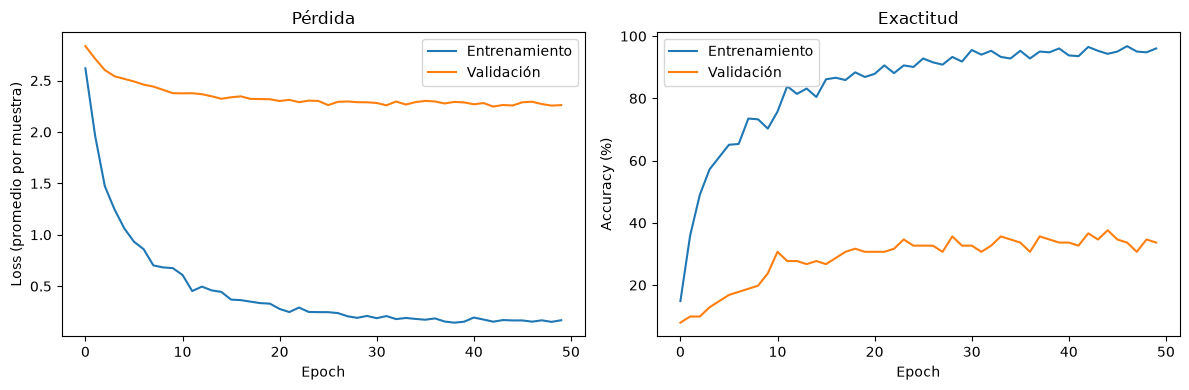

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

axes[0].plot(running_stats[:, 0], label='Entrenamiento')
axes[0].plot(running_stats[:, 2], label='Validación')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (promedio por muestra)')
axes[0].set_title('Pérdida')
axes[0].legend()

axes[1].plot(running_stats[:, 1] * 100, label='Entrenamiento')
axes[1].plot(running_stats[:, 3] * 100, label='Validación')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Exactitud')
axes[1].legend()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

In [10]:
test_loader  = tdata.DataLoader(test_dataset, shuffle=False, batch_size=64)
test_targets = np.array(test_dataset.dataset.labels)[test_dataset.indices]

model.eval()
prediction_test = []
for images, labels, names, attributes in test_loader:
    images     = images.to(device)
    attributes = attributes.to(device)
    logits = model(images, attributes).detach()
    prediction_test.append(logits.argmax(dim=1).cpu().numpy())
prediction_test = np.concatenate(prediction_test)

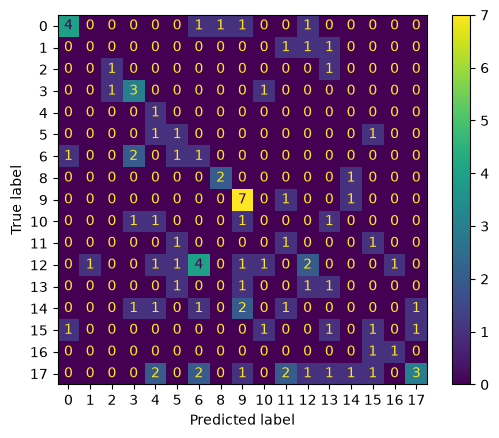

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(test_targets, prediction_test);

In [12]:
print(classification_report(test_targets, prediction_test, digits=3))

              precision    recall  f1-score   support

           0      0.667     0.500     0.571         8
           1      0.000     0.000     0.000         3
           2      0.500     0.500     0.500         2
           3      0.429     0.600     0.500         5
           4      0.143     1.000     0.250         1
           5      0.200     0.333     0.250         3
           6      0.111     0.200     0.143         5
           8      0.667     0.667     0.667         3
           9      0.500     0.778     0.609         9
          10      0.000     0.000     0.000         4
          11      0.167     0.333     0.222         3
          12      0.333     0.167     0.222        12
          13      0.167     0.250     0.200         4
          14      0.000     0.000     0.000         7
          15      0.200     0.200     0.200         5
          16      0.500     0.500     0.500         2
          17      0.600     0.214     0.316        14

    accuracy              

### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

In [48]:
print(test_dataset.dataset.categories)

['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting', 'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice', 'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water']


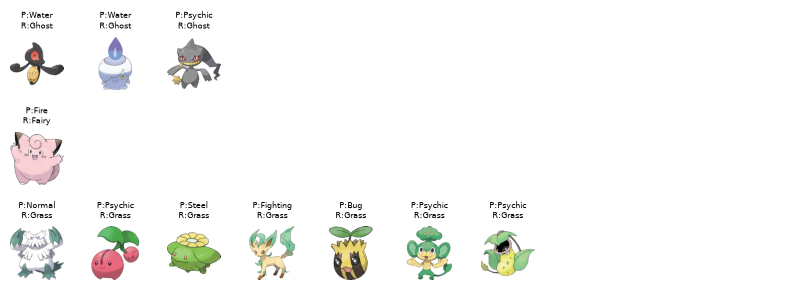

In [52]:
# wow
categories = test_dataset.dataset.categories

fig, ax = plt.subplots(3, 10, figsize=(8, 3), tight_layout=True)

for k, digit in enumerate([8, 4, 9]):
    idx = np.where((test_targets == digit) & ~(prediction_test == digit))[0]
    for i in range(10):
        ax[k, i].axis('off')
        if i < len(idx):
            real_label = test_targets[idx[i]]
            pred_label = prediction_test[idx[i]]
            real_name = categories[real_label]
            pred_name = categories[pred_label]
            ax[k, i].set_title(f"P:{pred_name}\nR:{real_name}", fontsize=6)
            ax[k, i].imshow(test_dataset[idx[i]][0].numpy().transpose(1, 2, 0))

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [12]:
# wow2